<a href="https://colab.research.google.com/github/iam-mukeshvenkatesh/Machine-Learning-Laboratory/blob/main/EDA_DIABETES_refined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis — Diabetes Dataset

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on a diabetes dataset that contains missing values. The workflow covers:

1. **Data Loading & Initial Inspection** — shape, data types, first rows
2. **Missing Value Detection & Imputation** — mean-based fill strategy
3. **Duplicate Detection**
4. **Statistical Summary**
5. **Outlier Detection & Removal** — IQR method with boxplot visualisations
6. **Distribution Analysis** — histograms per feature
7. **Correlation Analysis** — heatmap
8. **Target Variable Distribution** — class balance check
9. **Scatter-Plot Matrix** — pairwise feature relationships coloured by class


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


## 2. Data Loading & Initial Inspection


In [3]:
df = pd.read_csv("Diabetes Missing Data.csv")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print("Column data types:")
print(df.dtypes)
print()
print("First 10 rows:")
df.head(10)


Shape: 768 rows × 9 columns

Column data types:
Pregnant               int64
Glucose              float64
Diastolic_BP         float64
Skin_Fold            float64
Serum_Insulin        float64
BMI                  float64
Diabetes_Pedigree    float64
Age                    int64
Class                  int64
dtype: object

First 10 rows:


,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


## 3. Missing Value Analysis

We count missing values per column and visualise their proportion before deciding on an imputation strategy.


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
print(missing_df if not missing_df.empty else "None — no missing values detected.")


Columns with missing values:
               Missing Count  Missing %
Serum_Insulin            374      48.70
Skin_Fold                227      29.56
Diastolic_BP              35       4.56
BMI                       11       1.43
Glucose                    5       0.65


## 4. Duplicate Detection

Duplicate rows can skew statistics and model training. We identify and report them here.


In [5]:
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

if n_duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated()])
    # Drop duplicates to keep data clean
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"\nDataset shape after removing duplicates: {df.shape}")


Number of duplicate rows: 0


## 5. Missing Value Imputation

Numeric columns with missing values are filled with their **column mean**. This is a simple and common strategy when missingness is low and approximately random (check missing % above before applying more advanced techniques).


In [6]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    if df[col].isnull().any():
        mean_value = df[col].mean()
        df[col] = df[col].fillna(mean_value)   # avoids deprecated inplace on chain
        print(f"  Filled '{col}' with mean = {mean_value:.4f}")

print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
df.head(10)


  Filled 'Glucose' with mean = 121.6868
  Filled 'Diastolic_BP' with mean = 72.4052
  Filled 'Skin_Fold' with mean = 29.1534
  Filled 'Serum_Insulin' with mean = 155.5482
  Filled 'BMI' with mean = 32.4575

Missing values remaining: 0


,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6,148.0,72.000000,35.00000,155.548223,33.600000,0.627,50,1
1,1,85.0,66.000000,29.00000,155.548223,26.600000,0.351,31,0
2,8,183.0,64.000000,29.15342,155.548223,23.300000,0.672,32,1
3,1,89.0,66.000000,23.00000,94.000000,28.100000,0.167,21,0
4,0,137.0,40.000000,35.00000,168.000000,43.100000,2.288,33,1
5,5,116.0,74.000000,29.15342,155.548223,25.600000,0.201,30,0
6,3,78.0,50.000000,32.00000,88.000000,31.000000,0.248,26,1
7,10,115.0,72.405184,29.15342,155.548223,35.300000,0.134,29,0
8,2,197.0,70.000000,45.00000,543.000000,30.500000,0.158,53,1
9,8,125.0,96.000000,29.15342,155.548223,32.457464,0.232,54,1


## 6. Statistical Summary

`describe()` gives count, mean, std, min, quartiles, and max for every numeric feature — a quick health-check for the data.


In [7]:
df.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
Pregnant,768.0,3.845,3.370,0.000,1.000,3.000,6.000,17.00
Glucose,768.0,121.687,30.436,44.000,99.750,117.000,140.250,199.00
Diastolic_BP,768.0,72.405,12.096,24.000,64.000,72.203,80.000,122.00
Skin_Fold,768.0,29.153,8.791,7.000,25.000,29.153,32.000,99.00
Serum_Insulin,768.0,155.548,85.021,14.000,121.500,155.548,155.548,846.00
BMI,768.0,32.457,6.875,18.200,27.500,32.400,36.600,67.10
Diabetes_Pedigree,768.0,0.472,0.331,0.078,0.244,0.372,0.626,2.42
Age,768.0,33.241,11.760,21.000,24.000,29.000,41.000,81.00
Class,768.0,0.349,0.477,0.000,0.000,0.000,1.000,1.00


## 7. Boxplot — Before Outlier Removal

A boxplot per feature reveals the spread, median, and suspected outliers.


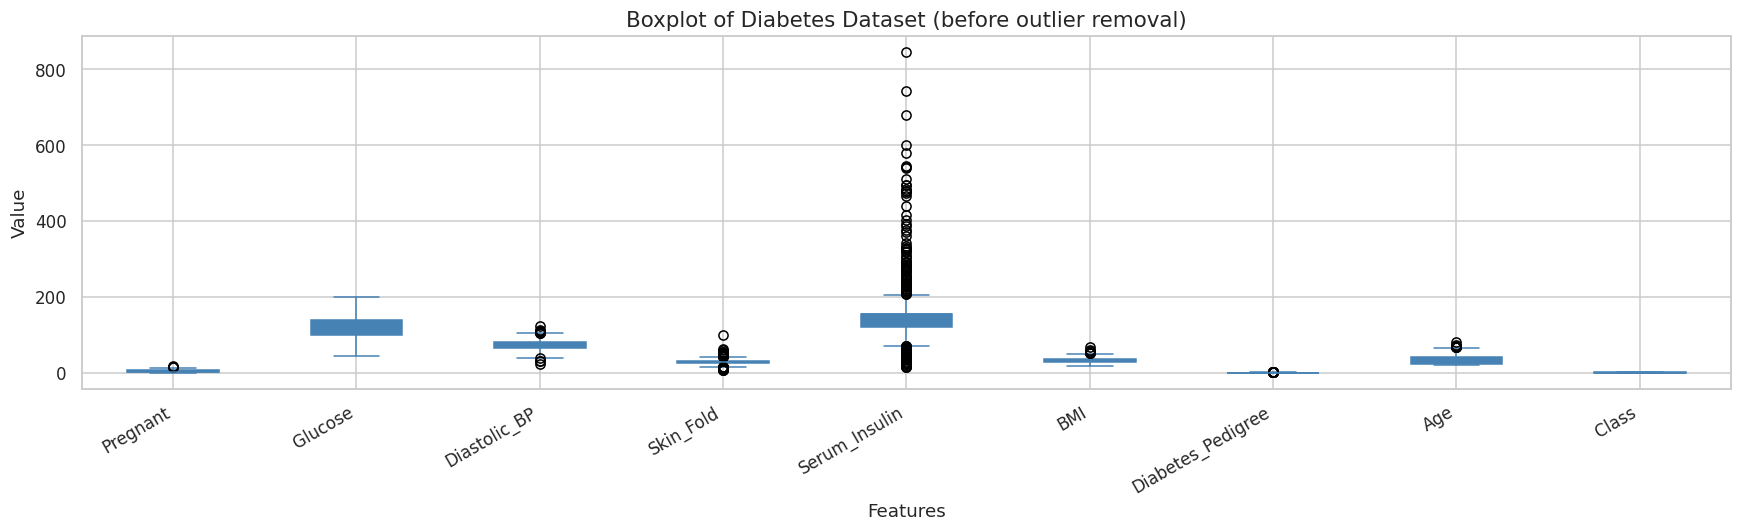

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
df.plot(kind='box', ax=ax, color='steelblue', patch_artist=True)
ax.set_title("Boxplot of Diabetes Dataset (before outlier removal)", fontsize=14)
ax.set_xlabel("Features")
ax.set_ylabel("Value")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 8. Outlier Removal (IQR Method)

We apply the **IQR (Inter-Quartile Range)** rule: a value is considered an outlier if it falls below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR. We clip only *numeric* columns so that any categorical target column is left intact.


In [9]:
df_clean = df.copy()

# Apply IQR filtering only to numeric feature columns
# If 'Class' is numeric but is actually a label, exclude it
feature_cols = [c for c in numeric_cols if c != 'Class']

n_before = len(df_clean)
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

n_after = len(df_clean)
print(f"Rows before outlier removal : {n_before}")
print(f"Rows after  outlier removal : {n_after}")
print(f"Outlier rows removed        : {n_before - n_after} ({(n_before - n_after)/n_before*100:.1f}%)")


Rows before outlier removal : 768
Rows after  outlier removal : 462
Outlier rows removed        : 306 (39.8%)


### Boxplot — After Outlier Removal


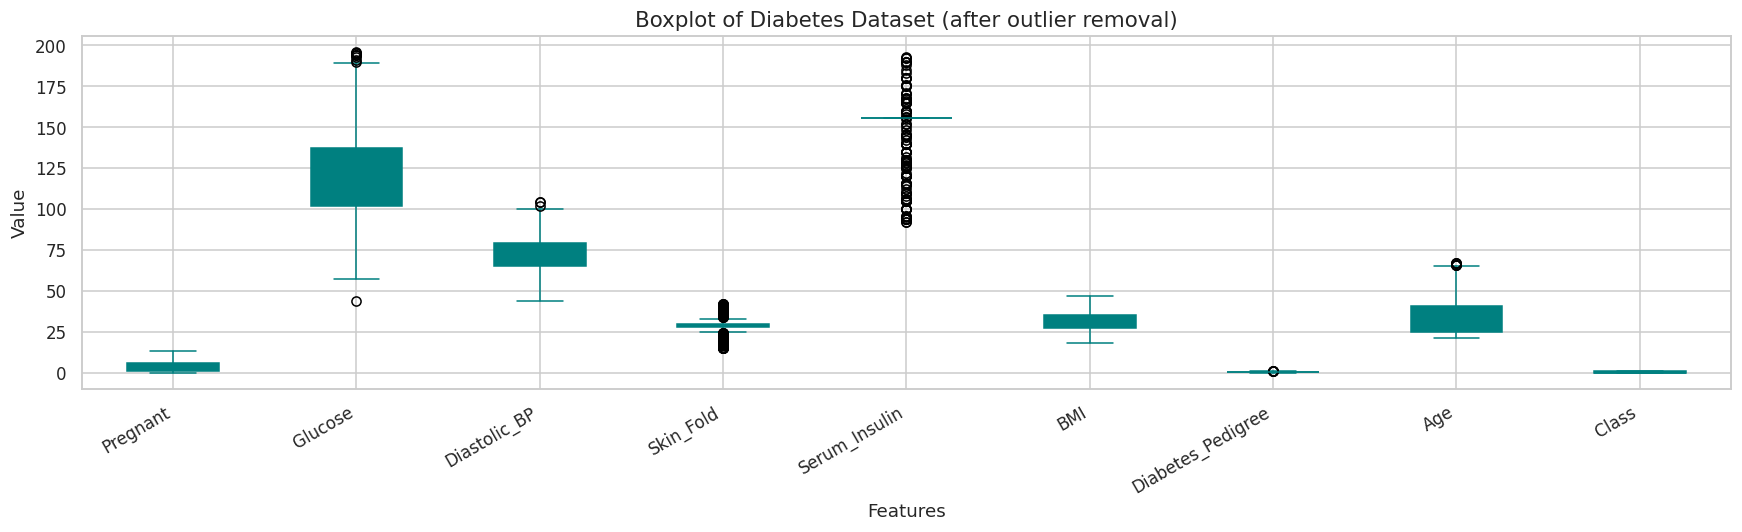

In [10]:
fig, ax = plt.subplots(figsize=(16, 5))
df_clean.plot(kind='box', ax=ax, color='teal', patch_artist=True)
ax.set_title("Boxplot of Diabetes Dataset (after outlier removal)", fontsize=14)
ax.set_xlabel("Features")
ax.set_ylabel("Value")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 9. Feature Distributions (Histograms)

Histograms reveal the shape of each feature's distribution — whether it is roughly normal, skewed, bimodal, etc. This guides further preprocessing decisions.


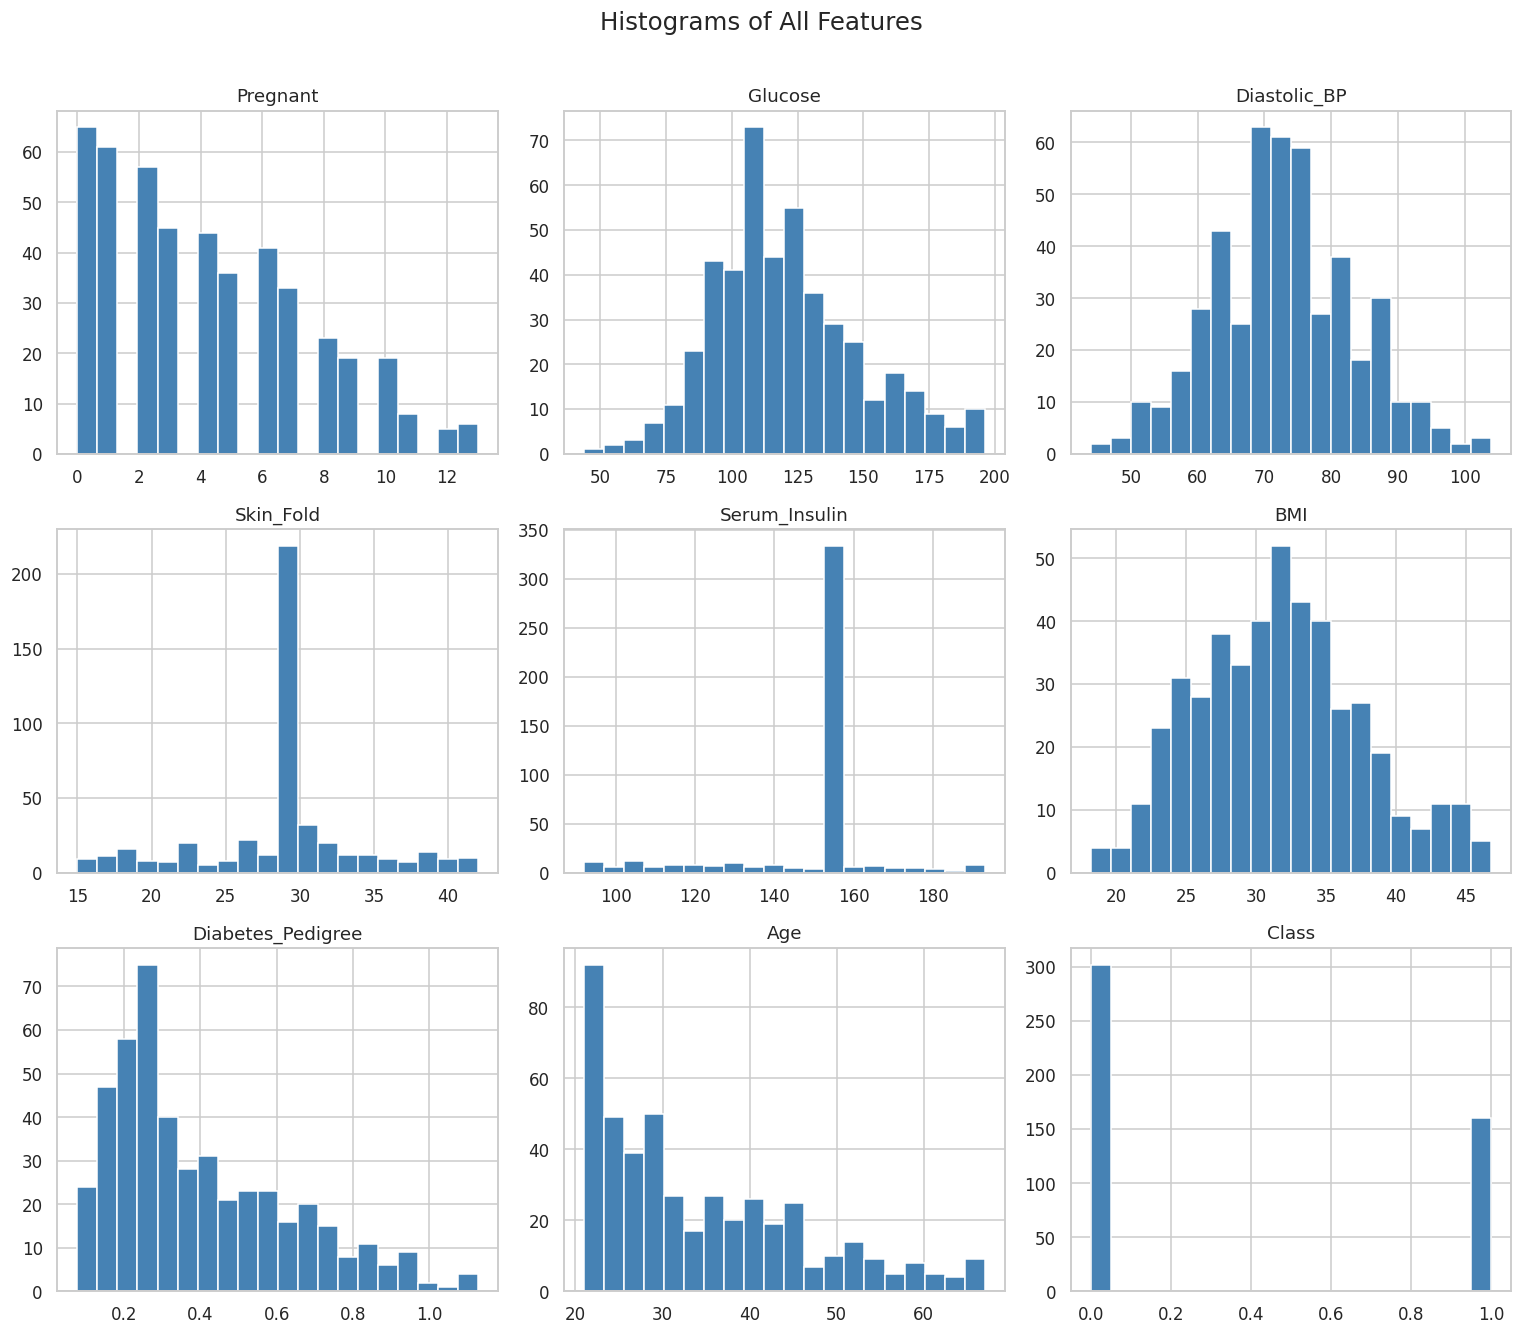

In [11]:
df_clean.hist(figsize=(14, 12), bins=20, edgecolor='white', color='steelblue')
plt.suptitle("Histograms of All Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## 10. Correlation Heatmap

A heatmap of Pearson correlations highlights which features are linearly related. Strong correlations (positive or negative) may indicate redundancy or important predictive signals.


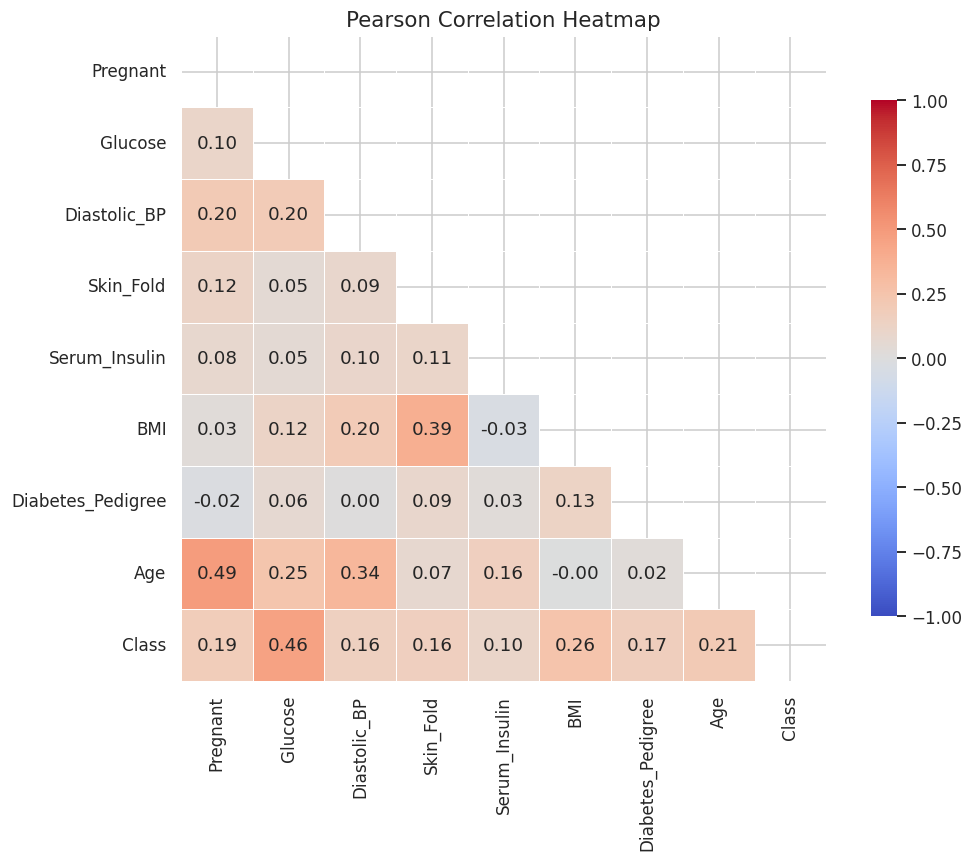

In [12]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


## 11. Target Variable Distribution

For a classification task the balance of classes is critical — a heavily imbalanced target can mislead accuracy metrics and bias a model toward the majority class.


Class distribution:
Class
0    302
1    160
Name: count, dtype: int64

Imbalance ratio: 1.89


/tmp/ipykernel_1490/2052472824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df_clean, palette='Set2', ax=axes[0])


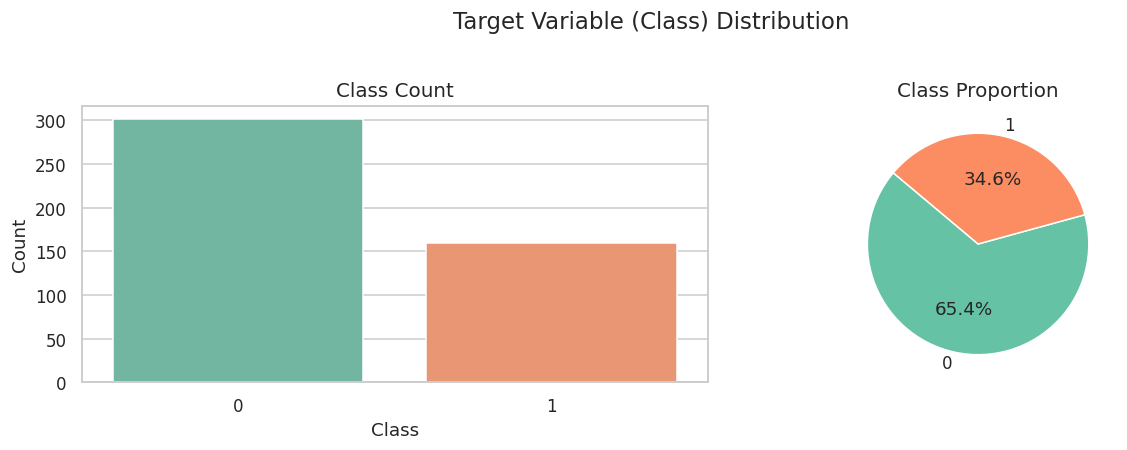

In [13]:
if 'Class' in df_clean.columns:
    class_counts = df_clean['Class'].value_counts().sort_index()
    print("Class distribution:")
    print(class_counts)
    print(f"\nImbalance ratio: {class_counts.max() / class_counts.min():.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Count plot
    sns.countplot(x='Class', data=df_clean, palette='Set2', ax=axes[0])
    axes[0].set_title("Class Count", fontsize=13)
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")

    # Pie chart
    axes[1].pie(
        class_counts, labels=class_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('Set2', len(class_counts))
    )
    axes[1].set_title("Class Proportion", fontsize=13)

    plt.suptitle("Target Variable (Class) Distribution", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No 'Class' column found — skipping target distribution plot.")


## 12. Scatter-Plot Matrix

The scatter-plot matrix (pair plot) shows pairwise feature relationships and lets us spot clusters or linear trends across classes.


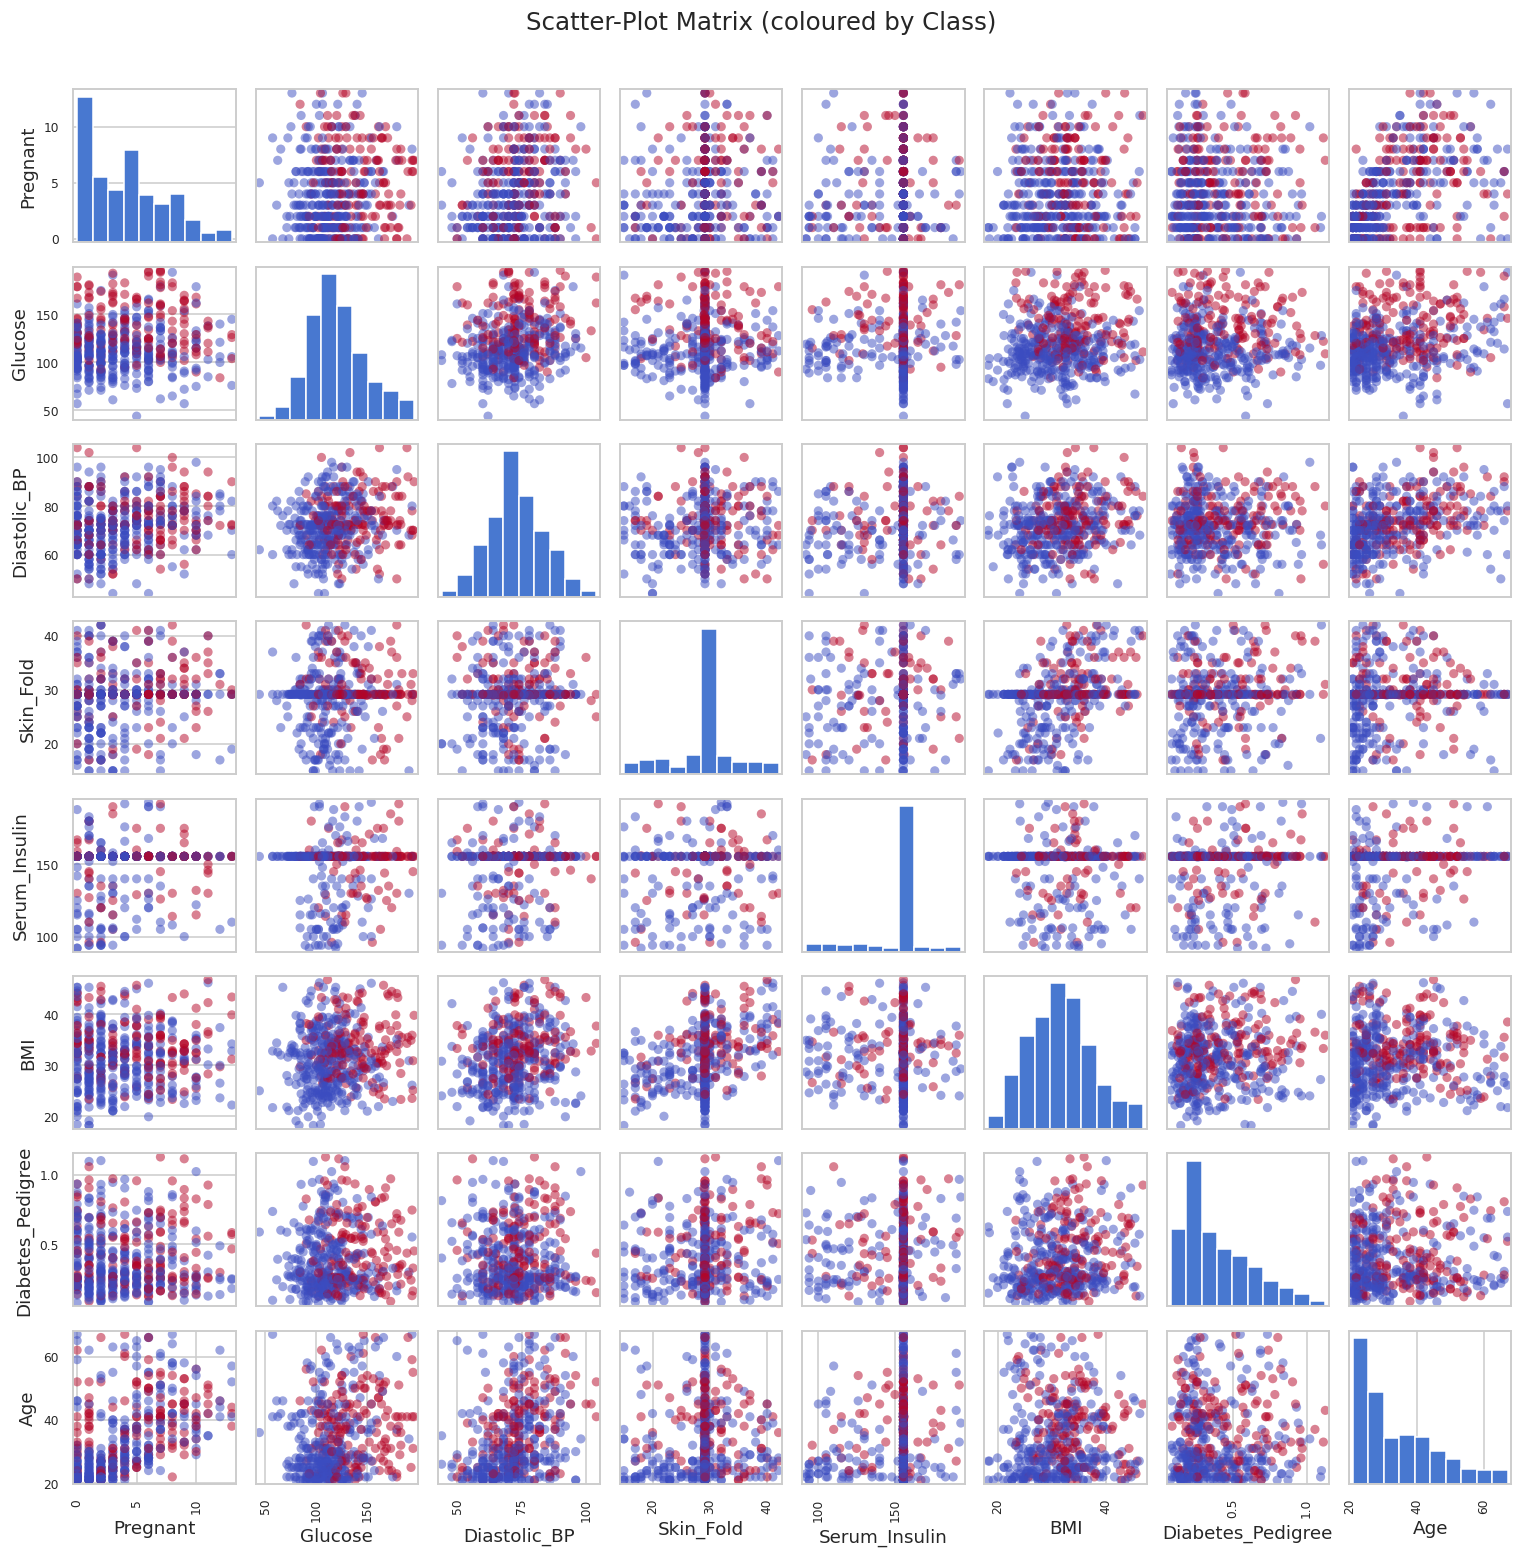

In [14]:
if 'Class' in df_clean.columns:
    # Convert Class to integer for colour mapping
    class_int = df_clean['Class'].astype(int)
    axes = pd.plotting.scatter_matrix(
        df_clean.drop(columns=['Class']),
        figsize=(14, 14),
        grid=True,
        marker='o',
        alpha=0.5,
        c=class_int,
        cmap='coolwarm'
    )
    plt.suptitle("Scatter-Plot Matrix (coloured by Class)", fontsize=16, y=1.01)
else:
    axes = pd.plotting.scatter_matrix(
        df_clean,
        figsize=(14, 14),
        grid=True,
        marker='o',
        alpha=0.5
    )
    plt.suptitle("Scatter-Plot Matrix", fontsize=16, y=1.01)

plt.tight_layout()
plt.show()
